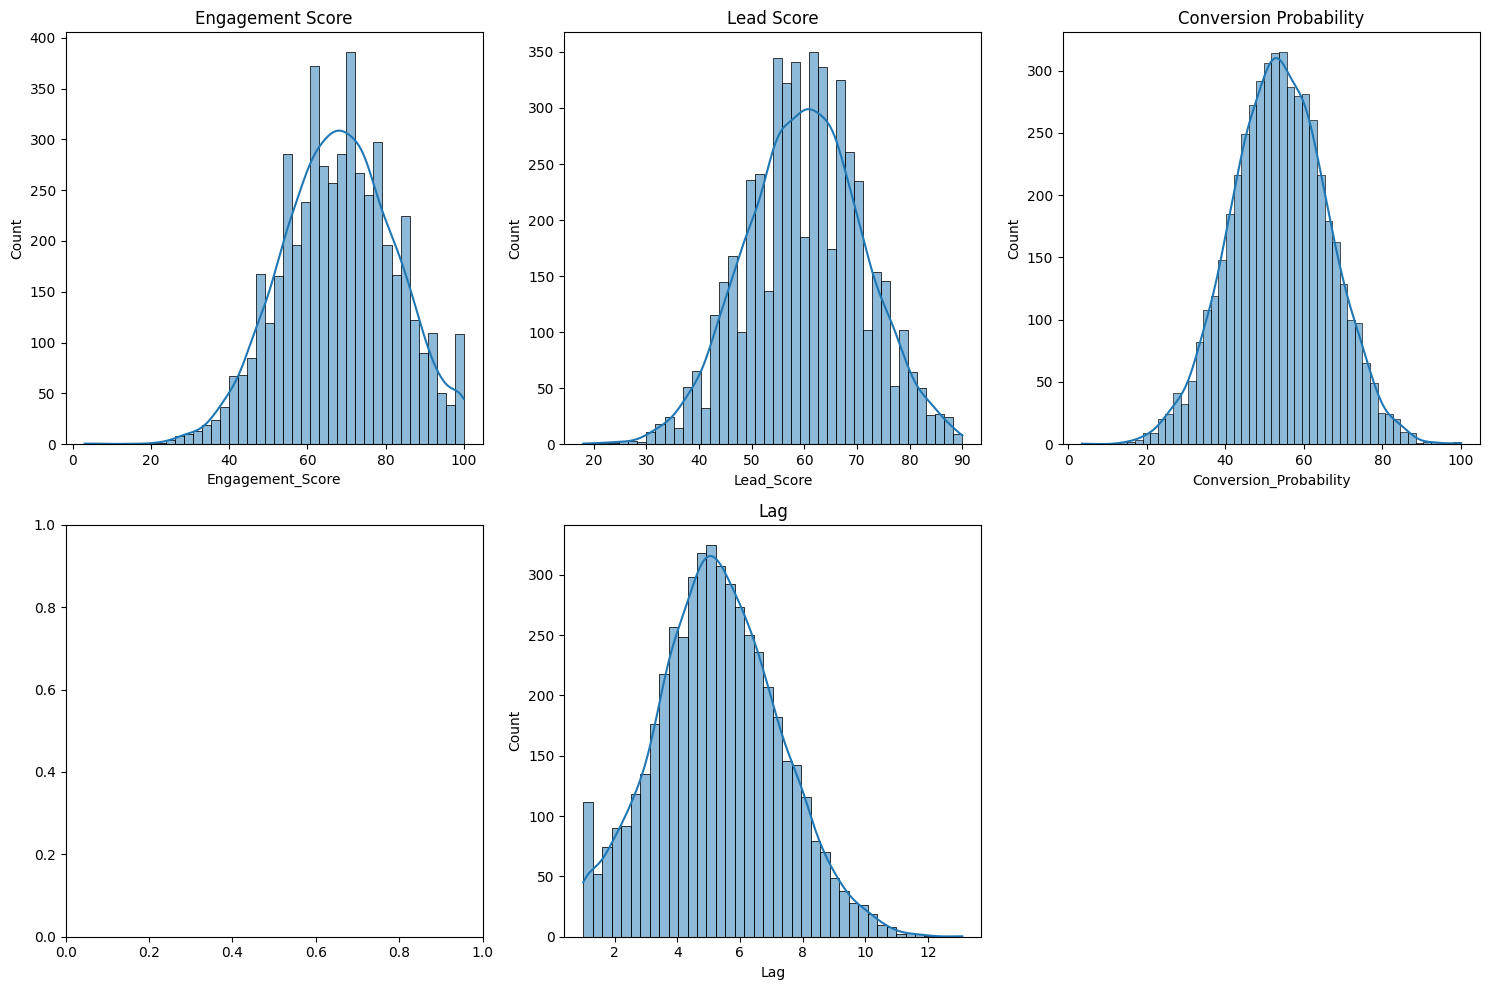

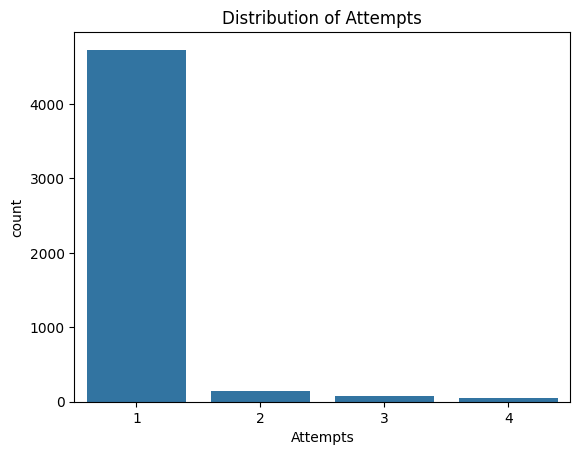

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\Lenovo\Downloads\Actual_Data_Final.csv")

fig, axes = plt.subplots(2, 3, figsize=(15,10))

sns.histplot(df['Engagement_Score'], kde=True, ax=axes[0,0])
axes[0,0].set_title('Engagement Score')

sns.histplot(df['Lead_Score'], kde=True, ax=axes[0,1])
axes[0,1].set_title('Lead Score')

sns.histplot(df['Conversion_Probability'], kde=True, ax=axes[0,2])
axes[0,2].set_title('Conversion Probability')

sns.histplot(df['Lag'], kde=True, ax=axes[1,1])
axes[1,1].set_title('Lag')

axes[1,2].axis('off')

plt.tight_layout()
plt.show()

sns.countplot(x='Attempts', data=df)
plt.title('Distribution of Attempts')
plt.show()


In [16]:


long_pitch = df[df["Pitch_Category"]=="Long"]["Engagement_Score"]
medium_pitch = df[df["Pitch_Category"]=="Medium"]["Engagement_Score"]
short_pitch = df[df["Pitch_Category"]=="Short"]["Engagement_Score"]

f_stat, p_val = f_oneway(
    long_pitch,
    medium_pitch,
    short_pitch
)

print("Pitch Compression ANOVA")
print("F-Statistic:", f_stat)
print("P-Value:", p_val)

Pitch Compression ANOVA
F-Statistic: 216.30257984408686
P-Value: 8.06937195570186e-91


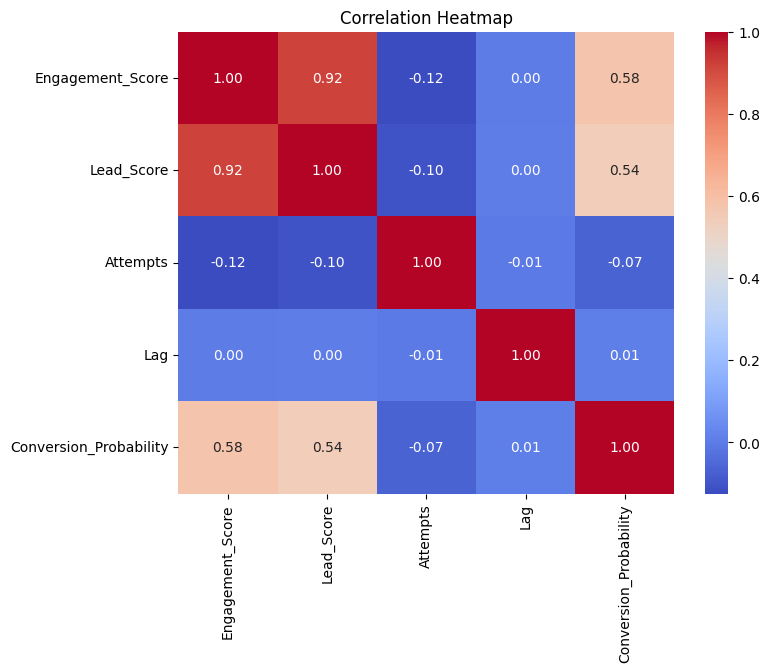

In [17]:
corrcols=["Engagement_Score","Lead_Score","Attempts","Lag","Conversion_Probability"]
df[corrcols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    df[corrcols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [18]:
from scipy.stats import f_oneway

formal = df[df["Script_Tone"]=="Formal"]["Engagement_Score"]

semi_formal = df[
    df["Script_Tone"]=="Semi-Formal"
]["Engagement_Score"]

casual = df[
    df["Script_Tone"]=="Casual"
]["Engagement_Score"]

f_stat, p_val = f_oneway(
    formal,
    semi_formal,
    casual
)

print("\nScript Tone ANOVA")
print("F-Statistic:", f_stat)
print("P-Value:", p_val)



Script Tone ANOVA
F-Statistic: 147.88280847970628
P-Value: 4.019554369997973e-63


In [19]:
same_day = df[
    df["Followup_Gap"]=="Same Day"
]["Engagement_Score"]

one_day = df[
    df["Followup_Gap"]=="1 Day"
]["Engagement_Score"]

two_days = df[
    df["Followup_Gap"]=="2 Days"
]["Engagement_Score"]

three_five = df[
    df["Followup_Gap"]=="3-5 Days"
]["Engagement_Score"]

f_stat, p_val = f_oneway(
    same_day,
    one_day,
    two_days,
    three_five
)

print("\nFollow-Up Gap ANOVA")
print("F-Statistic:", f_stat)
print("P-Value:", p_val)


Follow-Up Gap ANOVA
F-Statistic: 234.6222478432487
P-Value: 2.0255707012833654e-142


In [20]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(
    df["Attempts"],
    df["High_Engagement"]
)

chi2, p, dof, expected = chi2_contingency(
    contingency_table
)

print("\nAttempt Decay Chi-Square")

print("Chi2 Statistic:", chi2)
print("P-Value:", p)
print("Degrees of Freedom:", dof)


Attempt Decay Chi-Square
Chi2 Statistic: 44.19139795400114
P-Value: 1.3743034221928168e-09
Degrees of Freedom: 3


In [21]:
from scipy.stats import ttest_ind

direct = df[
    df["Outreach_Type"]=="Direct"
]["Engagement_Score"]

ambassador = df[
    df["Outreach_Type"]=="Campus Ambassador"
]["Engagement_Score"]

t_stat, p_val = ttest_ind(
    direct,
    ambassador,
    equal_var=False
)

print("\nNetwork Effect T-Test")

print("T Statistic:", t_stat)
print("P-Value:", p_val)


Network Effect T-Test
T Statistic: 0.5565978581726612
P-Value: 0.577845841956493


In [22]:
north = df[df["Region"]=="North"]["Engagement_Score"]

west = df[df["Region"]=="West"]["Engagement_Score"]

east = df[df["Region"]=="East"]["Engagement_Score"]

south = df[df["Region"]=="South"]["Engagement_Score"]

f_stat, p_val = f_oneway(
    north,
    west,
    east,
    south
)

print("\nRegional Reachability ANOVA")

print("F Statistic:", f_stat)
print("P Value:", p_val)


Regional Reachability ANOVA
F Statistic: 58.48672069795103
P Value: 3.7337873335585084e-37
